In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 200
# Dark Mode Plots
plt.style.use('dark_background')
import corner
import ast

In [36]:
# Make the corner plot for the MCMC results
system_name = 'J0248'
model_ver = 'sie'
mcmc_samples_path = f'../{system_name}/mcmc/{model_ver}_mcmc.dat'
samples = pd.read_csv(mcmc_samples_path, delim_whitespace=True, header=None, names=['chi2', 'z', 'vel_disp', 'x', 'y', 'ellip', 'pa' ])


In [37]:
samples

,chi2,z,vel_disp,x,y,ellip,pa
0,1.000000e+30,1.388400,313.8522,-0.305906,0.774676,0.015972,-59.87035
1,1.000000e+30,1.388480,313.7758,-0.306560,0.774650,0.008121,-59.83621
2,1.000000e+30,1.389660,313.9208,-0.304835,0.777918,-0.008327,-59.92208
3,1.000000e+30,1.390205,314.6360,-0.303411,0.774010,-0.013236,-59.88885
4,1.000000e+30,1.391438,314.7645,-0.294070,0.769966,-0.020625,-59.86636
...,...,...,...,...,...,...,...
3045,7.082493e+02,1.403417,317.7305,-0.405218,0.850874,0.461525,-57.27156
3046,7.056756e+02,1.404029,317.8321,-0.402966,0.854361,0.469501,-57.28540
3047,7.001996e+02,1.404167,317.3121,-0.397381,0.858902,0.465388,-57.23434
3048,7.022595e+02,1.404956,316.6558,-0.396554,0.858931,0.462313,-57.17578


In [38]:
masked_samples = samples.drop(columns=['chi2']).to_numpy()

In [28]:
# # Masked Samples with no accept column
# masked_samples = samples[samples['accept'] == 'accept'].copy()
# masked_samples = masked_samples.drop(columns=['accept', 'chi2']).to_numpy()
# masked_samples

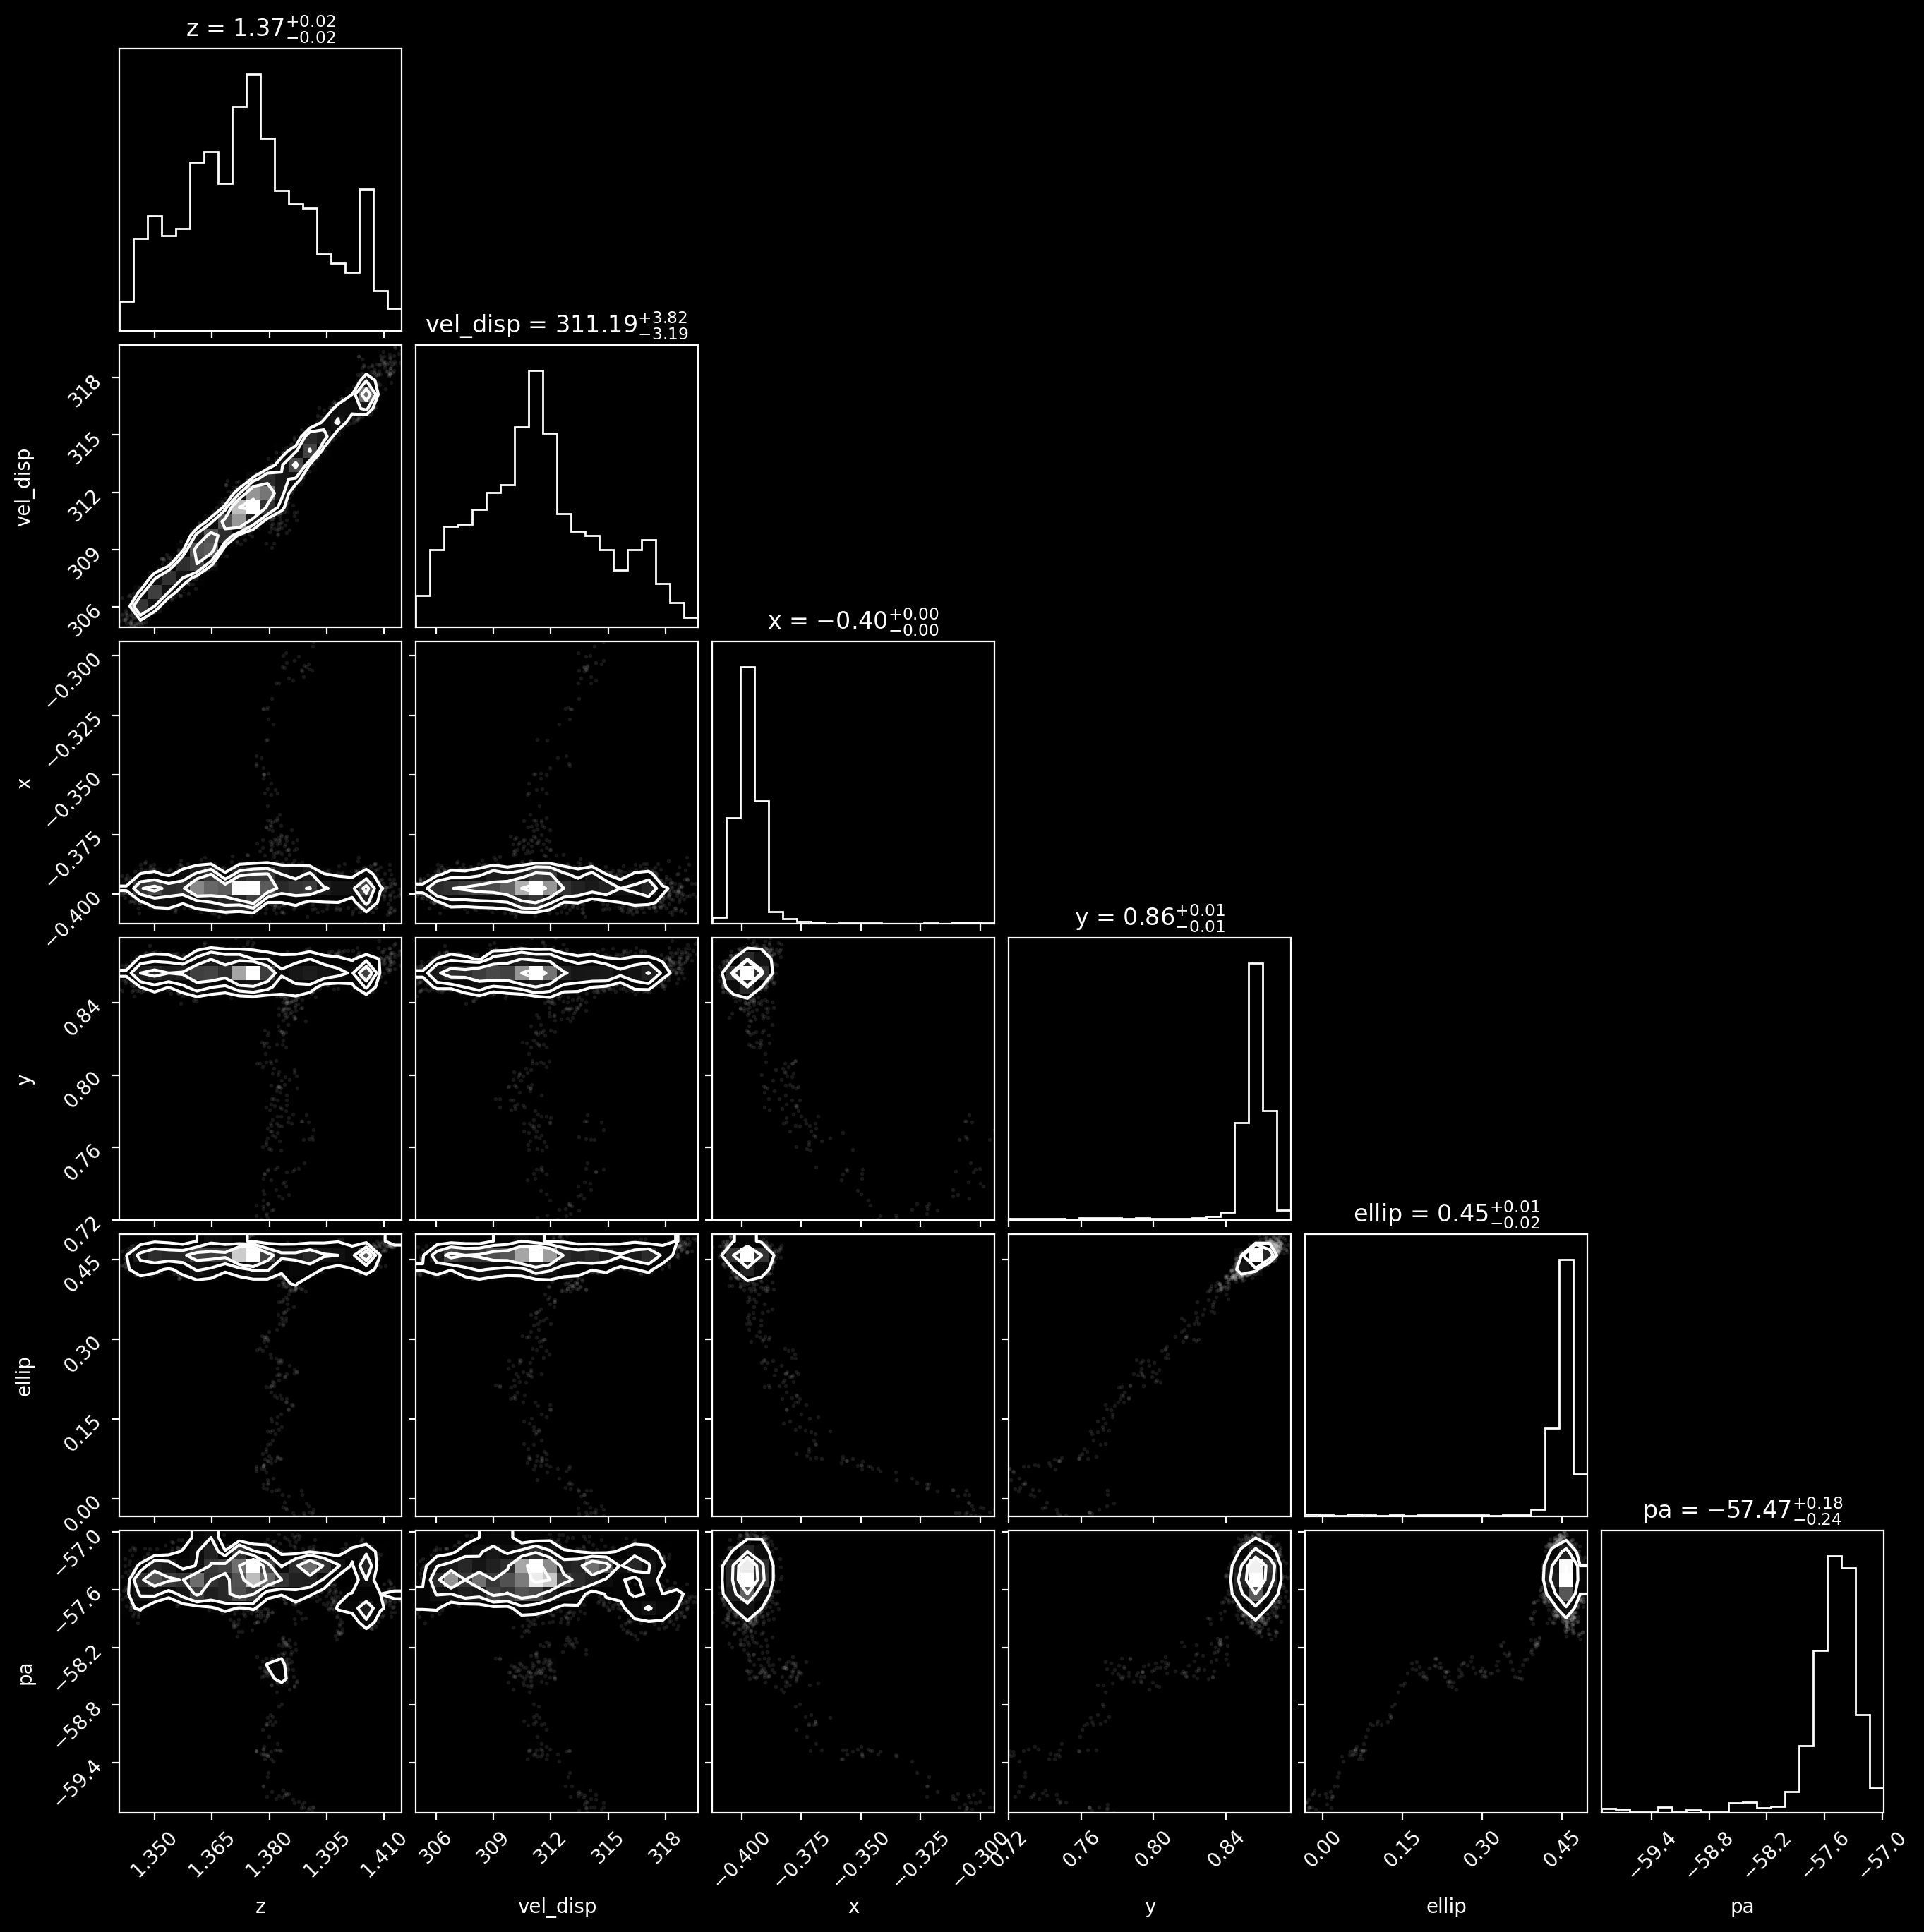

In [39]:
# Remove the first column when loading the samples, as it is the accepted/rejected column
labels = ['z', 'vel_disp', 'x', 'y', 'ellip', 'pa']
fig = corner.corner(masked_samples, labels=labels, show_titles=True)
plt.savefig(f'../{system_name}/mcmc/{model_ver}_corner.png')